In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler ,LabelEncoder
from sklearn.metrics import accuracy_score ,roc_auc_score ,confusion_matrix ,roc_curve

In [2]:
df=pd.read_csv('train.csv')
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [3]:
df.shape

(594194, 21)

In [4]:
df.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

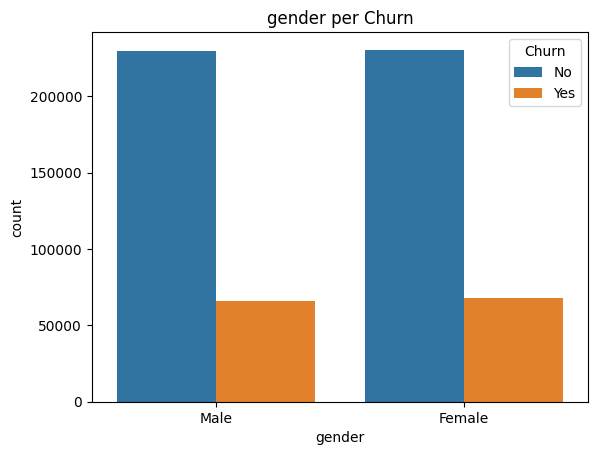

In [7]:
sns.countplot(x='gender',data=df,hue='Churn')
plt.title('gender per Churn')
plt.show()

In [8]:
df['gender'].value_counts()

gender
Female    298738
Male      295456
Name: count, dtype: int64

In [9]:
df['SeniorCitizen'].unique()

array([0, 1], dtype=int64)

In [10]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    526395
1     67799
Name: count, dtype: int64

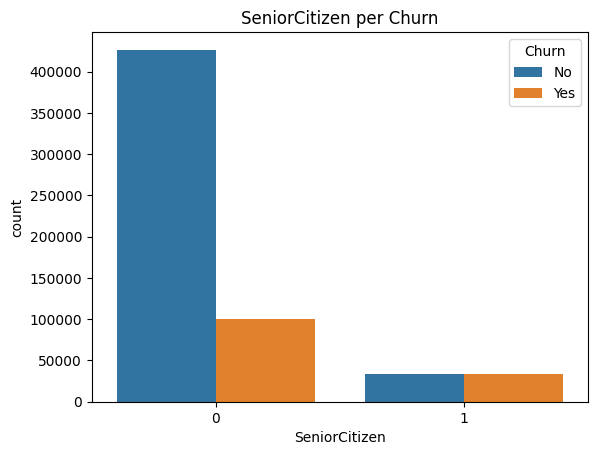

In [11]:
sns.countplot(x='SeniorCitizen',data=df,hue='Churn')
plt.title('SeniorCitizen per Churn')
plt.show()

In [12]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [13]:
df.drop('TotalCharges',axis=1,inplace=True)

In [14]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,Yes


In [15]:
df.dtypes

id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
Churn                object
dtype: object

In [16]:
df['Contract'].unique()

array(['One year', 'Two year', 'Month-to-month'], dtype=object)

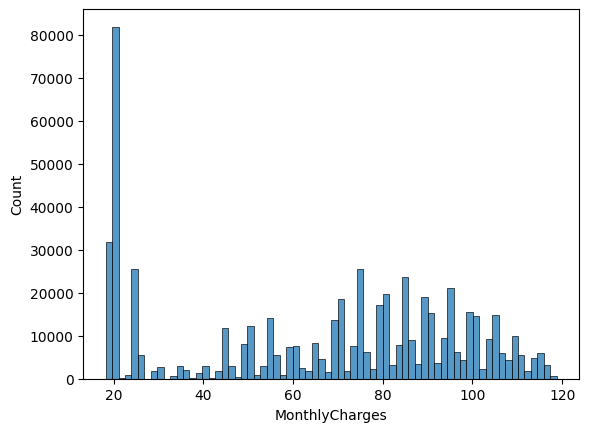

In [17]:
sns.histplot(x='MonthlyCharges',data=df)
plt.show()

In [18]:
num_pipline=Pipeline([('scaler',StandardScaler())])

In [19]:
catogry_cols=df.columns[df.dtypes=='object']

In [20]:
LabelEncoder().fit_transform(df['gender'])

array([1, 1, 1, ..., 0, 0, 0])

In [21]:
df[catogry_cols]

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,Male,Yes,Yes,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,No
1,Male,Yes,Yes,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),No
2,Male,Yes,No,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,No
3,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes
4,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,Male,No,No,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),No
594190,Female,No,No,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),No
594191,Female,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),No
594192,Female,No,No,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,No


In [22]:
for col in catogry_cols:
    df[col]=LabelEncoder().fit_transform(df[col])

In [23]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,1,0,1,1,29,1,0,0,2,0,2,2,0,0,1,1,3,60.10,0
1,1,1,0,1,1,58,1,0,0,2,2,0,2,2,0,2,0,1,69.50,0
2,2,1,0,1,0,58,1,2,1,0,2,0,0,2,2,0,1,2,100.40,0
3,3,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,2,69.70,1
4,4,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,2,70.45,1


## Machine Learning

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [25]:
x=df.drop(['id','Churn'],axis=1)
y=df['Churn']

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [27]:
lg=LogisticRegression(max_iter=1000)
lg.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [28]:
yhat=lg.predict(x_test)

In [29]:
roc_auc_score(y_test,lg.predict_proba(x_test)[:,1])

0.9048378278564696

In [30]:
accuracy_score(y_test,yhat)

0.8520771800503202

In [31]:
matrix=confusion_matrix(y_test,yhat)

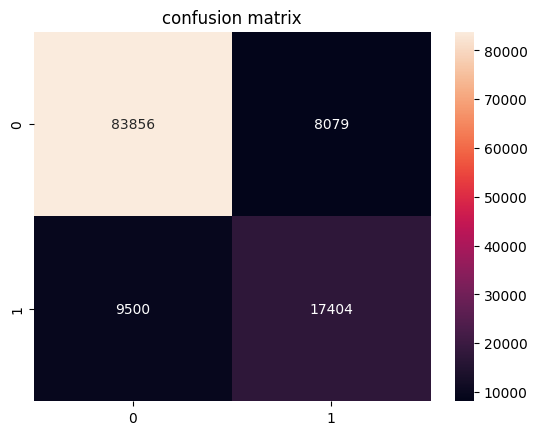

In [32]:
sns.heatmap(matrix,annot=True,fmt='1')
plt.title('confusion matrix')
plt.show()

In [33]:
fpr, tpr, thresholds=roc_curve(y_test,lg.predict_proba(x_test)[:,1])

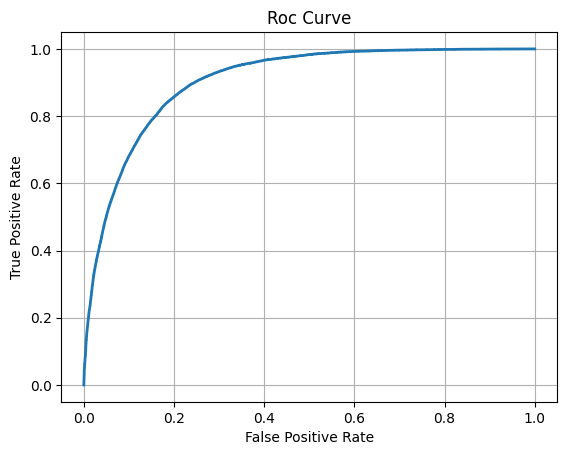

In [34]:
plt.plot(fpr,tpr,linewidth=2,)
plt.title('Roc Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.show()

In [38]:
from sklearn.model_selection import cross_val_score ,RandomizedSearchCV , StratifiedKFold
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [66]:
model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    class_weight='balanced'
)

scores = cross_val_score(
    model,
    x,
    y,
    cv=5,
    scoring="roc_auc"
)

[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040921 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 371
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039342 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 371
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 18
[LightGBM] [In

In [67]:
scores

array([0.91566169, 0.91348079, 0.9132202 , 0.91373366, 0.91247043])

In [42]:
cv=StratifiedKFold(n_splits=3,random_state=24,shuffle=True)

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42
)

# Hyperparameter space
param_dist = {
    'n_estimators': [300, 500, 800],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}



random_search=RandomizedSearchCV(xgb,param_distributions=param_dist,cv=cv,n_jobs=-1,scoring='roc_auc',random_state=42)
random_search.fit(x,y)

model=random_search.best_estimator_

scores = cross_val_score(
    model,
    x,
    y,
    cv=cv,
    scoring="roc_auc"
)

C:\Users\Get Into Pc\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [03:04:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Get Into Pc\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [03:05:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Get Into Pc\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [03:06:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Get Into Pc\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [03:

In [43]:
scores

array([0.91430782, 0.9133512 , 0.91413555])

In [68]:
model.fit(x,y)

[LightGBM] [Info] Number of positive: 133817, number of negative: 460377
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018407 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 371
[LightGBM] [Info] Number of data points in the train set: 594194, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               learning_rate=0.05, n_estimators=500, objective='binary',
               random_state=42, reg_alpha=0.1, reg_lambda=0.1, subsample=0.8)

In [69]:
df_test=pd.read_csv('test.csv')
df_test.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [70]:
x.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges
0,1,0,1,1,29,1,0,0,2,0,2,2,0,0,1,1,3,60.10
1,1,0,1,1,58,1,0,0,2,2,0,2,2,0,2,0,1,69.50
2,1,0,1,0,58,1,2,1,0,2,0,0,2,2,0,1,2,100.40
3,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,2,69.70
4,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,2,70.45


In [71]:
df_test.columns[df.dtypes=='object']

Index([], dtype='object')

In [72]:
for col in df_test.columns[df_test.dtypes=='object']:
    df_test[col]=LabelEncoder().fit_transform(df_test[col])

In [73]:
df_test.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,0,0,1,0,72,1,2,1,2,2,2,2,2,2,2,1,2,115.55,8061.50
1,594195,0,0,1,0,71,1,0,2,1,1,1,1,1,1,2,0,0,19.80,1336.50
2,594196,1,0,0,0,12,1,0,0,2,2,0,0,0,0,0,1,0,55.55,633.55
3,594197,1,0,1,1,71,1,2,0,2,0,2,2,2,2,2,0,1,84.10,6457.15
4,594198,0,0,0,0,15,1,0,1,2,0,0,0,2,2,0,0,2,90.35,1233.65


In [74]:
df_test.drop('TotalCharges',axis=1,inplace=True)

In [75]:
id=df_test['id']

In [76]:
df_test.dtypes

id                    int64
gender                int32
SeniorCitizen         int64
Partner               int32
Dependents            int32
tenure                int64
PhoneService          int32
MultipleLines         int32
InternetService       int32
OnlineSecurity        int32
OnlineBackup          int32
DeviceProtection      int32
TechSupport           int32
StreamingTV           int32
StreamingMovies       int32
Contract              int32
PaperlessBilling      int32
PaymentMethod         int32
MonthlyCharges      float64
dtype: object

In [77]:
y_proba=model.predict_proba(df_test.drop('id',axis=1))[:,1]

In [78]:
df_sub=pd.DataFrame({
    'id':id,
    'Churn':y_proba
})

In [79]:
df_sub.head()

,id,Churn
0,594194,0.143782
1,594195,0.002325
2,594196,0.273864
3,594197,0.009508
4,594198,0.765037


In [80]:
df_sub.to_csv('submission.csv',index=False)